In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [95]:
# LOAD ALL DATA ONCE
df = pd.read_csv('full_image_data_feb_25.csv')
books = pd.read_csv('full_book_data_feb_25.csv')

print(f"Total rows in df: {df.shape[0]}")
print(f"Total books: {df['book'].nunique()}")

Total rows in df: 27981
Total books: 342


## Rising and Setting (All 3 CKS)

In [96]:
# RISING & SETTING
rs_cks = ['CK_Heliacal Rising and Setting', 'CK_Chronical Rising and Setting', 'CK_Cosmic Rising and Setting']
rs_data = df[df['cks'].isin(rs_cks)].copy()

print(f"\n=== RISING & SETTING (All 3 CKS) ===")
print(f"Rows: {rs_data.shape[0]}, Books: {rs_data['book'].nunique()}, Images: {rs_data['images'].nunique()}")
print(rs_data['cks'].value_counts())


=== RISING & SETTING (All 3 CKS) ===
Rows: 146, Books: 82, Images: 92
cks
CK_Heliacal Rising and Setting     69
CK_Cosmic Rising and Setting       39
CK_Chronical Rising and Setting    38
Name: count, dtype: int64


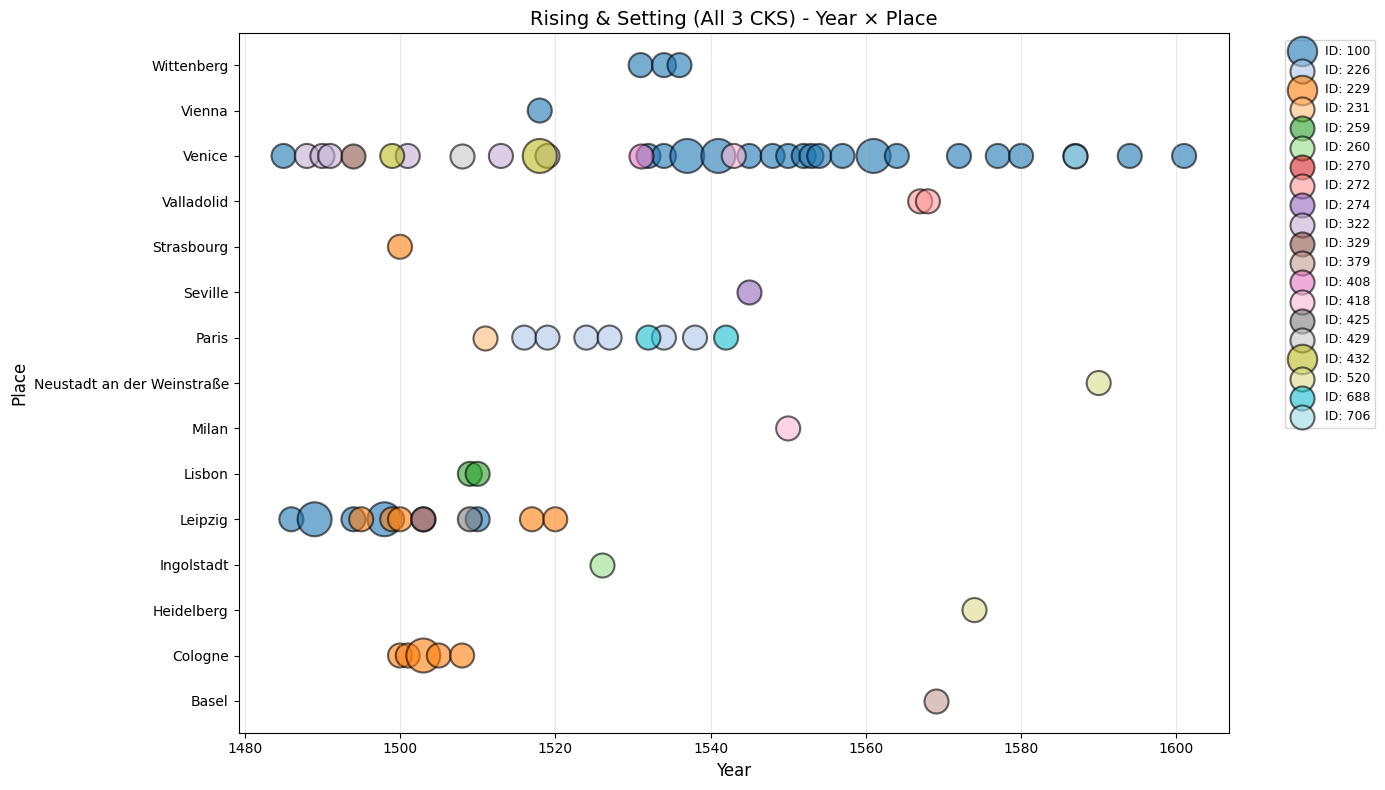

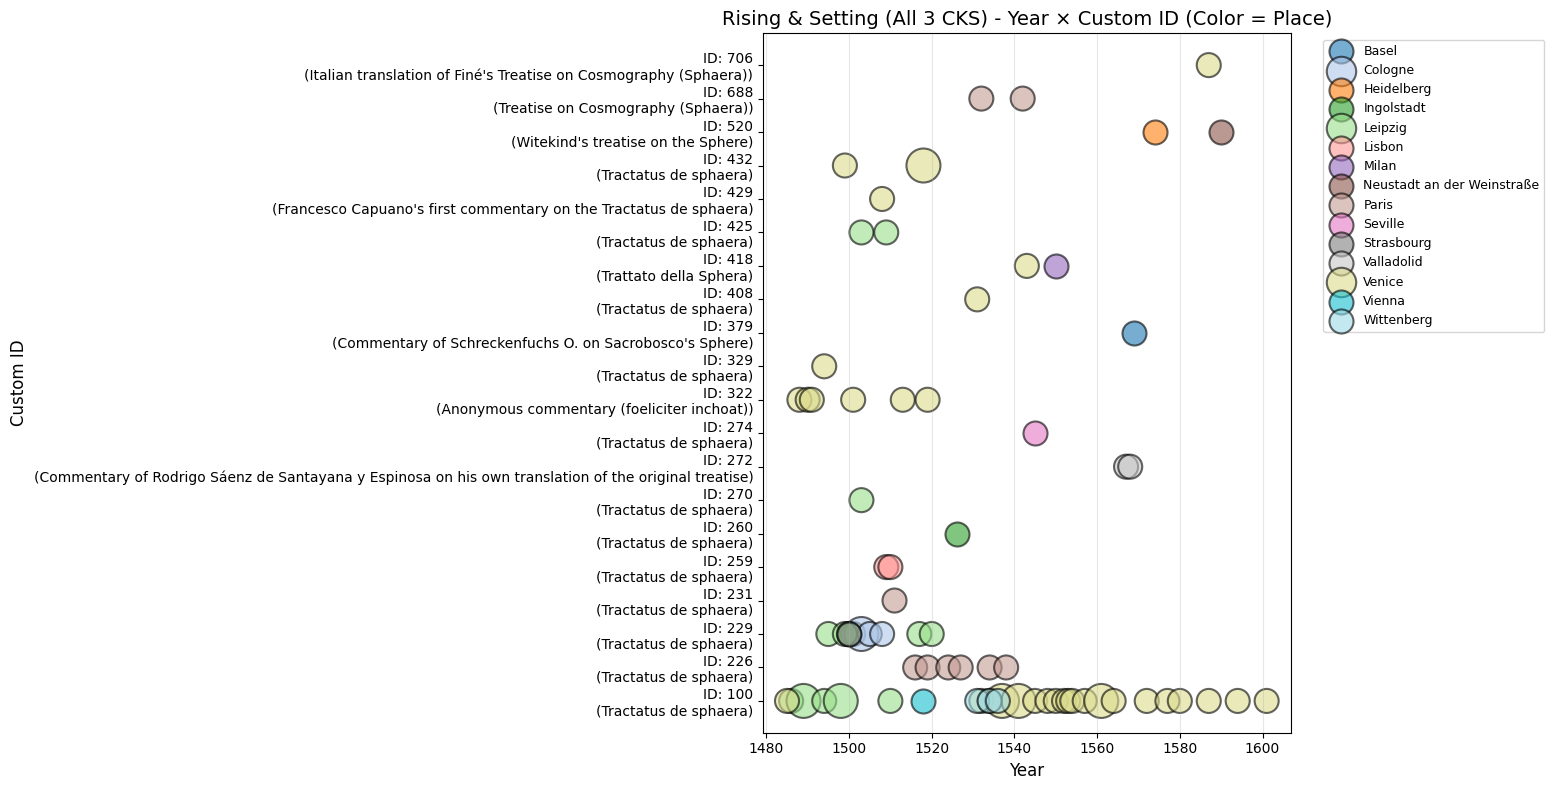

In [97]:
# Helper function for scatter plots
def make_scatter_plots(data, title_prefix):
    """Create Year×Place and Year×CustomID scatter plots"""
    
    # PLOT 1: Year × Place (Color = Custom ID)
    fig, ax = plt.subplots(figsize=(14, 8))
    
    plot_data = data.groupby(['year', 'place', 'custom_identifier']).agg({'book': 'nunique'}).reset_index()
    plot_data.columns = ['year', 'place', 'custom_id', 'num_books']
    
    places = sorted(plot_data['place'].dropna().unique())
    place_to_y = {place: i for i, place in enumerate(places)}
    custom_ids = sorted(plot_data['custom_id'].dropna().unique())
    colors = plt.cm.tab20(np.linspace(0, 1, len(custom_ids)))
    color_map = dict(zip(custom_ids, colors))
    
    for cid in custom_ids:
        subset = plot_data[plot_data['custom_id'] == cid]
        y_pos = [place_to_y[place] for place in subset['place']]
        ax.scatter(subset['year'], y_pos, s=subset['num_books'] * 300, alpha=0.6,
                  label=f"ID: {int(cid)}", color=color_map[cid], edgecolors='black', linewidth=1.5)
    
    ax.set_yticks(range(len(places)))
    ax.set_yticklabels(places)
    ax.set_xlabel('Year', fontsize=12)
    ax.set_ylabel('Place', fontsize=12)
    ax.set_title(f'{title_prefix} - Year × Place', fontsize=14)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
    ax.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()
    
    # PLOT 2: Year × Custom ID (Color = Place)
    fig, ax = plt.subplots(figsize=(16, 8))
    
    plot_data2 = data.groupby(['year', 'custom_identifier', 'place', 'part_or_adaption_label']).agg({'book': 'nunique'}).reset_index()
    plot_data2.columns = ['year', 'custom_id', 'place', 'part_or_adaption', 'num_books']
    
    custom_ids_y = sorted(plot_data2['custom_id'].dropna().unique())
    custom_id_to_y = {cid: i for i, cid in enumerate(custom_ids_y)}
    places = sorted(plot_data2['place'].dropna().unique())
    colors = plt.cm.tab20(np.linspace(0, 1, len(places)))
    color_map = dict(zip(places, colors))
    
    for place in places:
        subset = plot_data2[plot_data2['place'] == place]
        y_pos = [custom_id_to_y[cid] for cid in subset['custom_id']]
        ax.scatter(subset['year'], y_pos, s=subset['num_books'] * 300, alpha=0.6,
                  color=color_map[place], edgecolors='black', linewidth=1.5, label=place)
    
    y_labels = [f"ID: {int(cid)}\n({plot_data2[plot_data2['custom_id'] == cid]['part_or_adaption'].iloc[0]})" 
                for cid in custom_ids_y]
    ax.set_yticks(range(len(custom_ids_y)))
    ax.set_yticklabels(y_labels, fontsize=10)
    ax.set_xlabel('Year', fontsize=12)
    ax.set_ylabel('Custom ID', fontsize=12)
    ax.set_title(f'{title_prefix} - Year × Custom ID (Color = Place)', fontsize=14)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
    ax.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()

make_scatter_plots(rs_data, 'Rising & Setting (All 3 CKS)')

## Heliacal Rising and Setting (Individual)


=== HELIACAL ONLY ===
Rows: 69, Books: 69, Images: 69


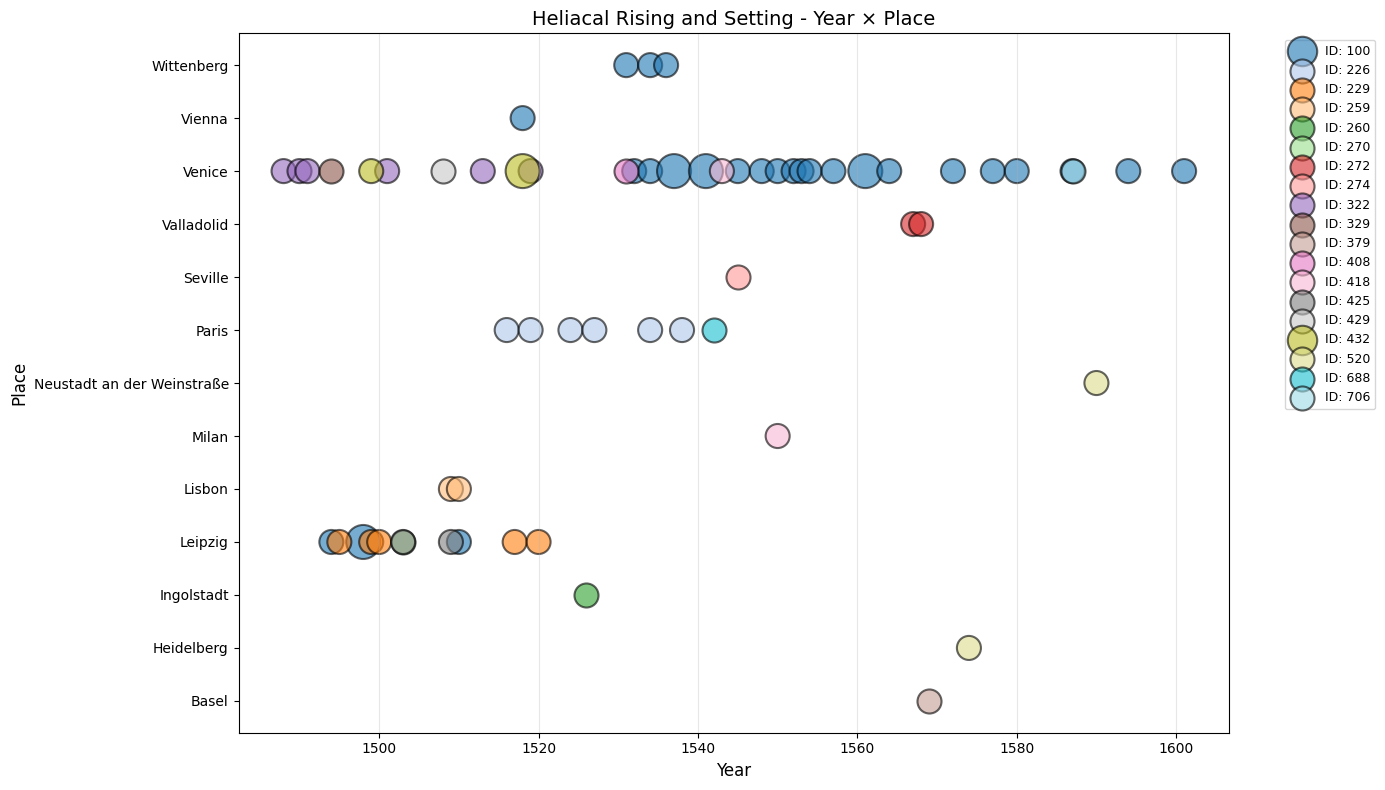

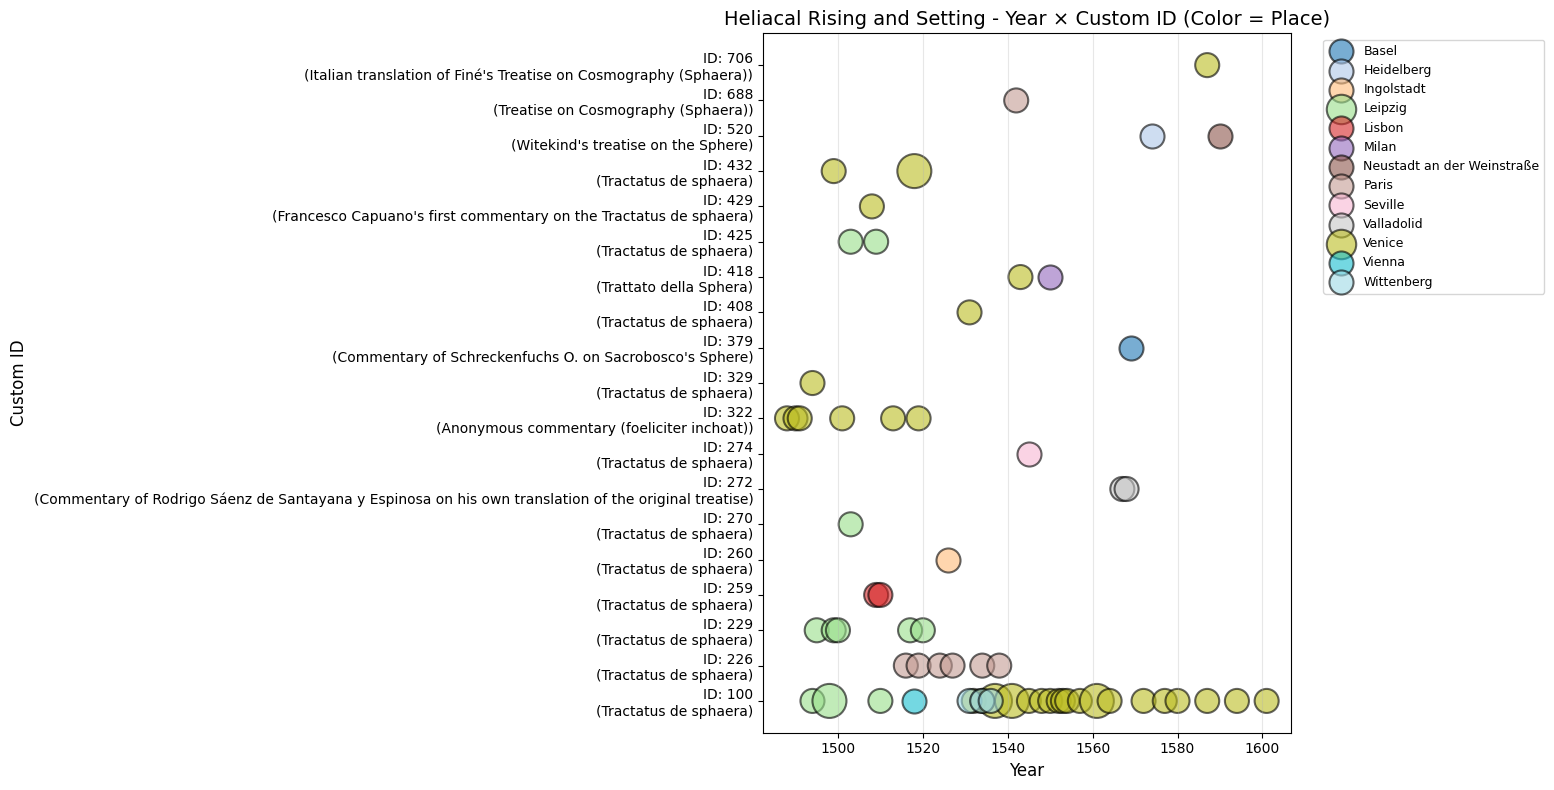

In [98]:
# HELIACAL ONLY
heliacal_data = df[df['cks'] == 'CK_Heliacal Rising and Setting'].copy()

print(f"\n=== HELIACAL ONLY ===")
print(f"Rows: {heliacal_data.shape[0]}, Books: {heliacal_data['book'].nunique()}, Images: {heliacal_data['images'].nunique()}")

make_scatter_plots(heliacal_data, 'Heliacal Rising and Setting')

## Ascensions (All 3 CKS)


=== ASCENSIONS (All 3 CKS) ===
Rows: 600, Books: 175, Images: 585
cks
CK_Ascensions in the Right and Oblique Sphere                  489
CK_Ascensions                                                   89
CK_Relations between Arcs of the Zodiac and the Equinoctial     22
Name: count, dtype: int64


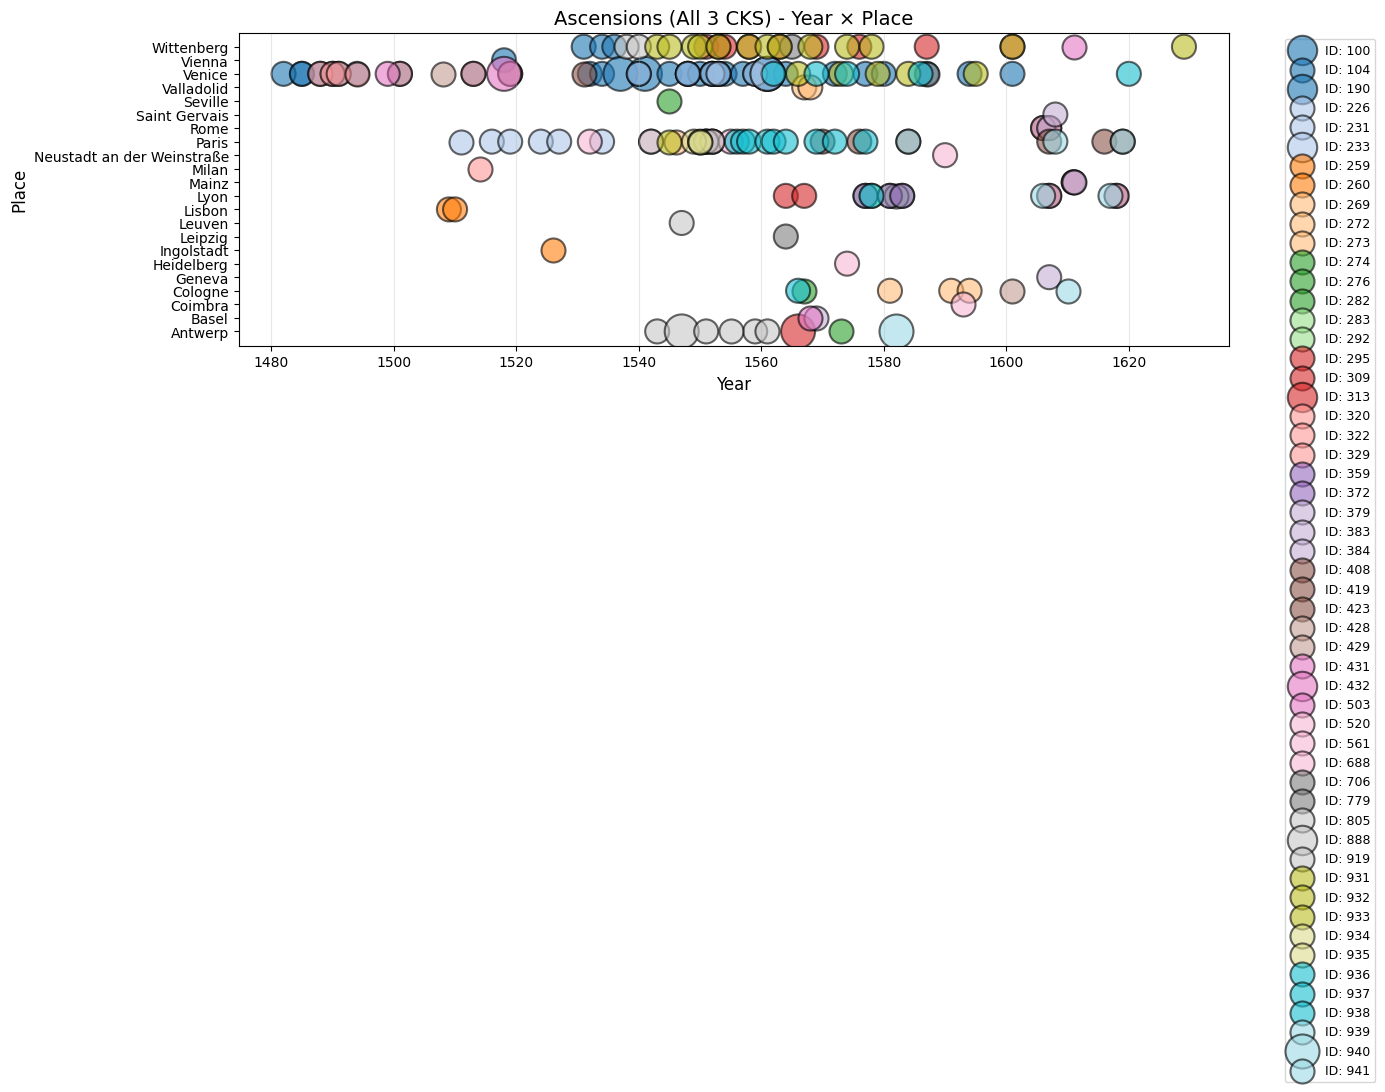

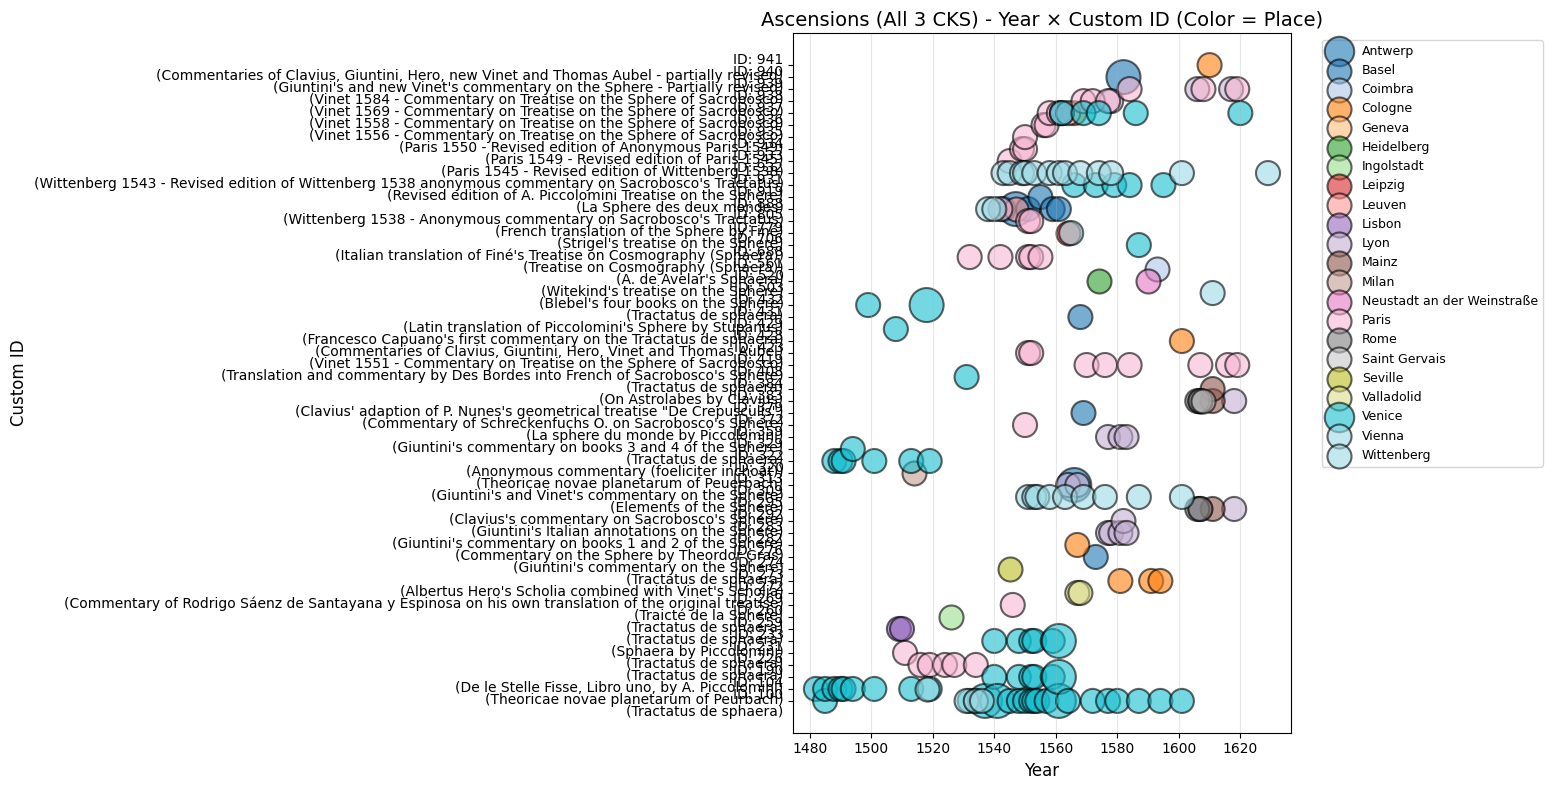

In [99]:
# ASCENSIONS - ALL 3
asc_cks = ['CK_Ascensions', 'CK_Ascensions in the Right and Oblique Sphere', 'CK_Relations between Arcs of the Zodiac and the Equinoctial']
asc_all_data = df[df['cks'].isin(asc_cks)].copy()

print(f"\n=== ASCENSIONS (All 3 CKS) ===")
print(f"Rows: {asc_all_data.shape[0]}, Books: {asc_all_data['book'].nunique()}, Images: {asc_all_data['images'].nunique()}")
print(asc_all_data['cks'].value_counts())

make_scatter_plots(asc_all_data, 'Ascensions (All 3 CKS)')

## Individual Ascensions CKS Values


=== CK_Ascensions ===
Rows: 89, Books: 29, Images: 74


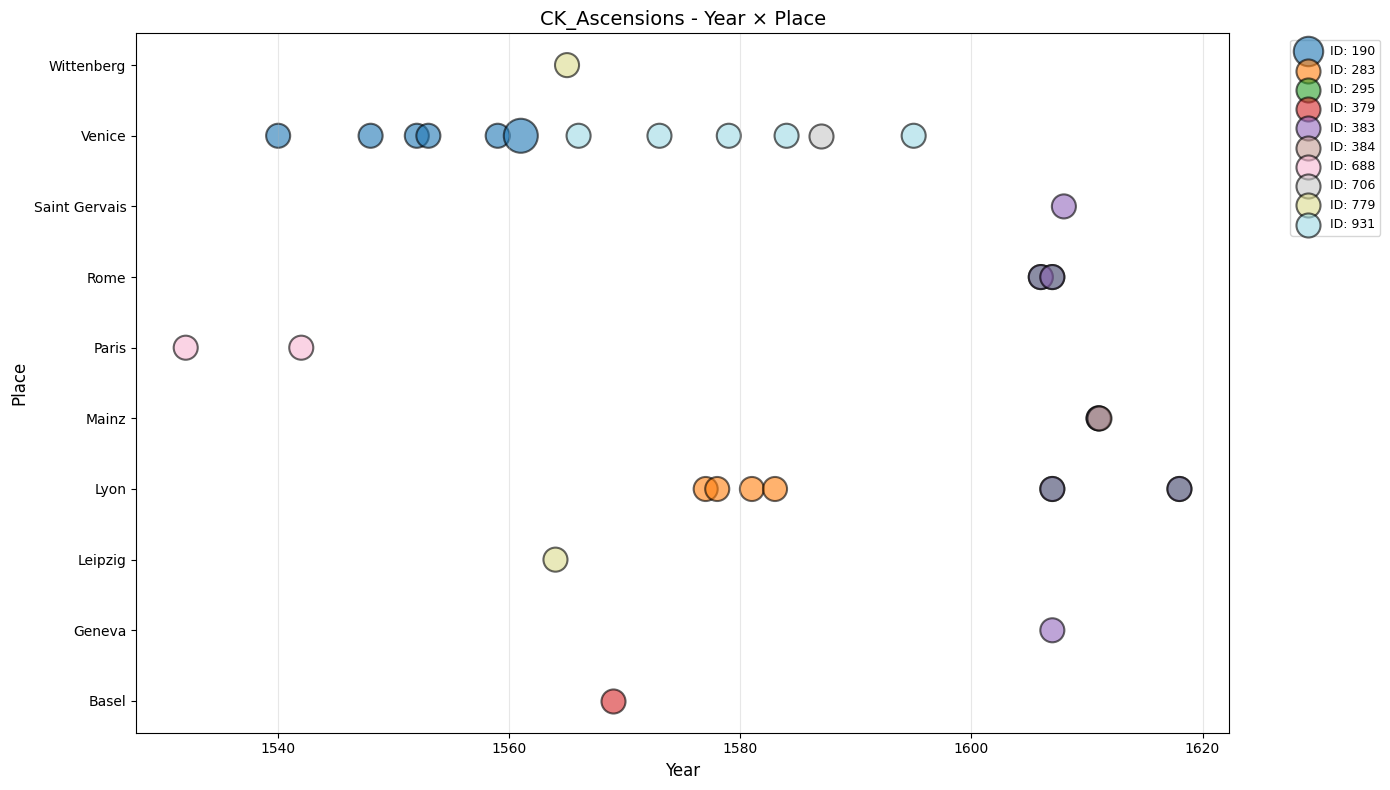

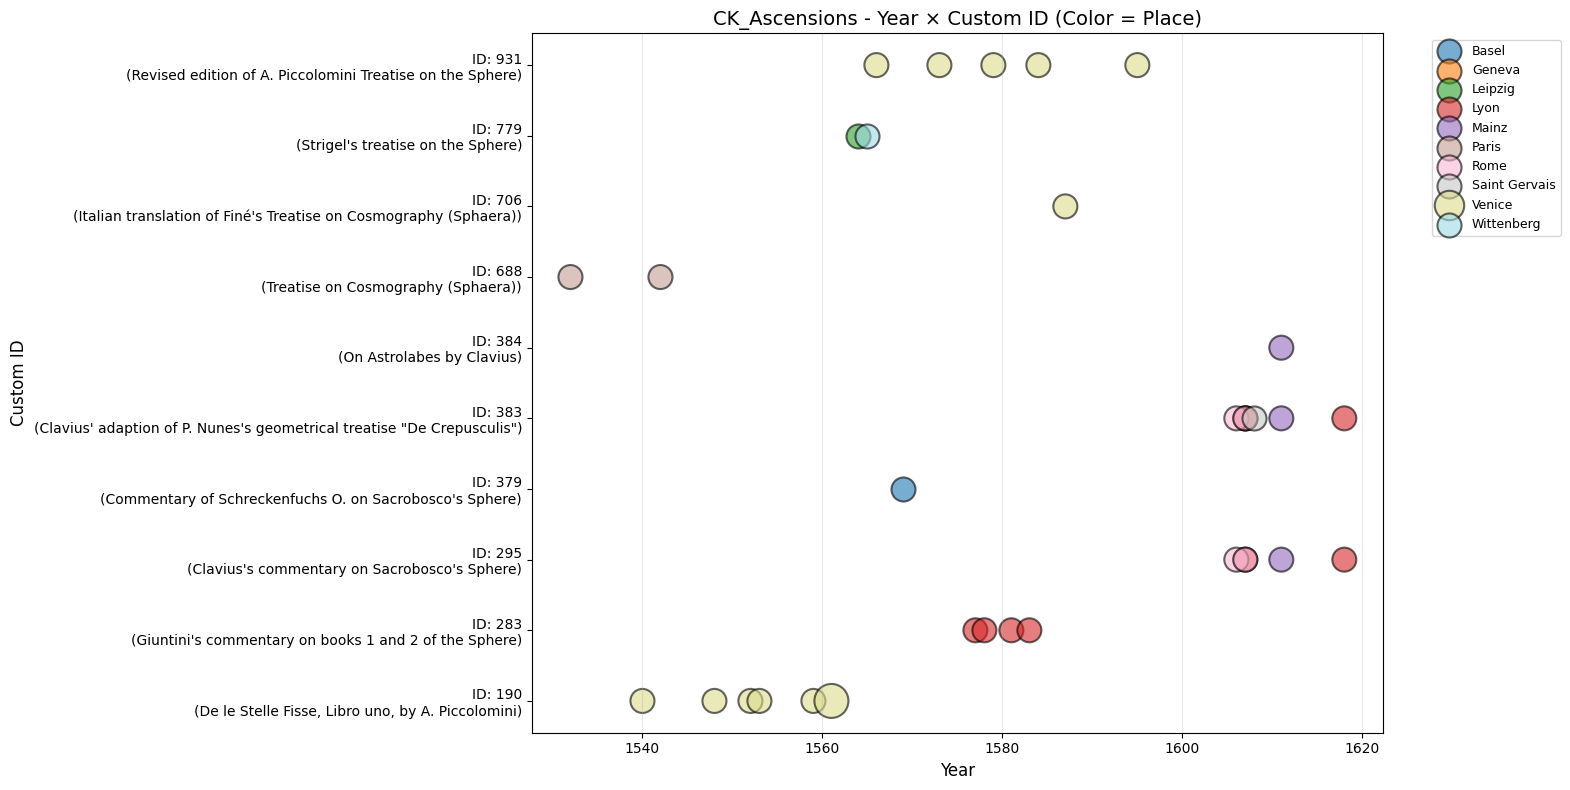


=== CK_Ascensions in the Right and Oblique Sphere ===
Rows: 489, Books: 152, Images: 489


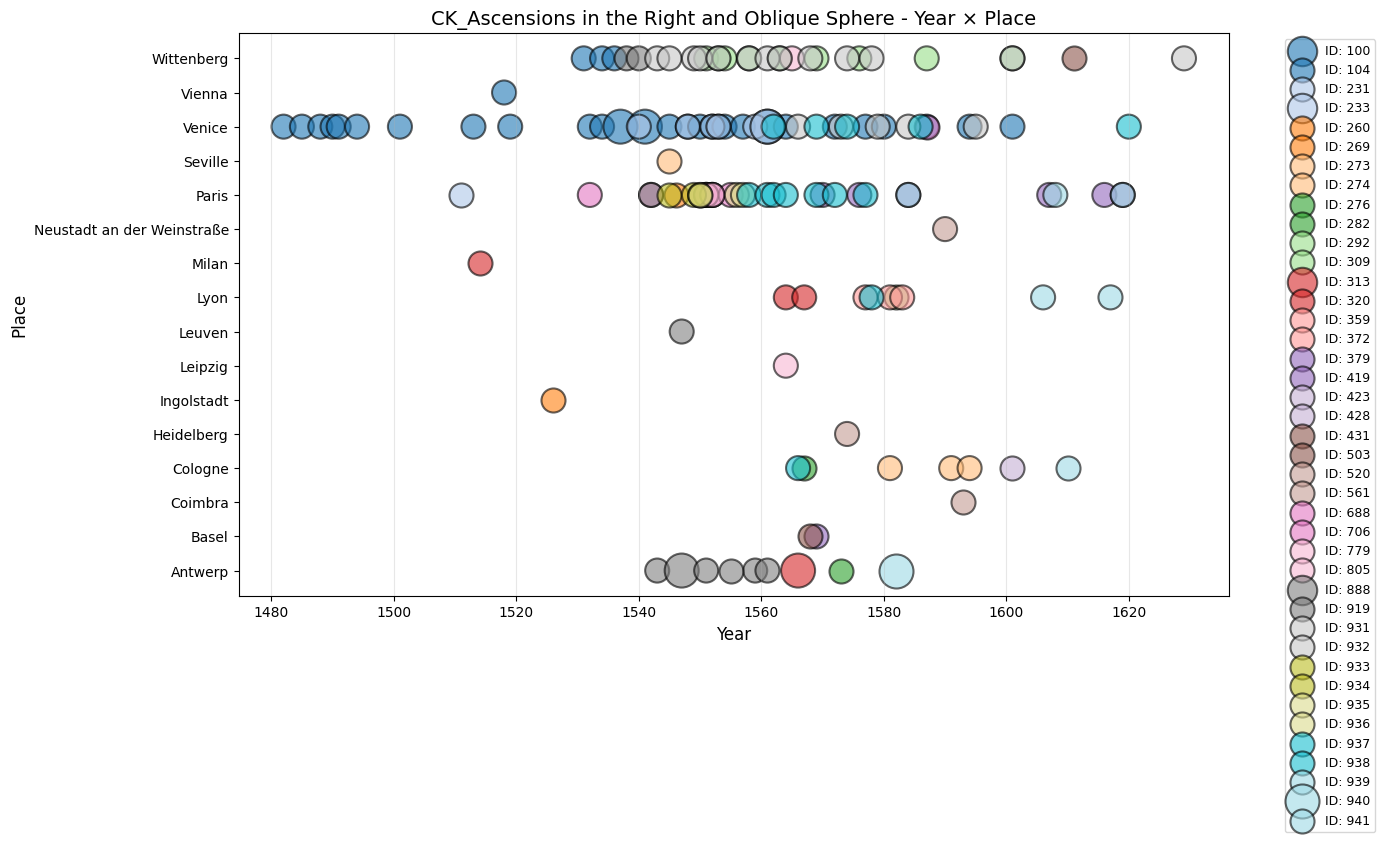

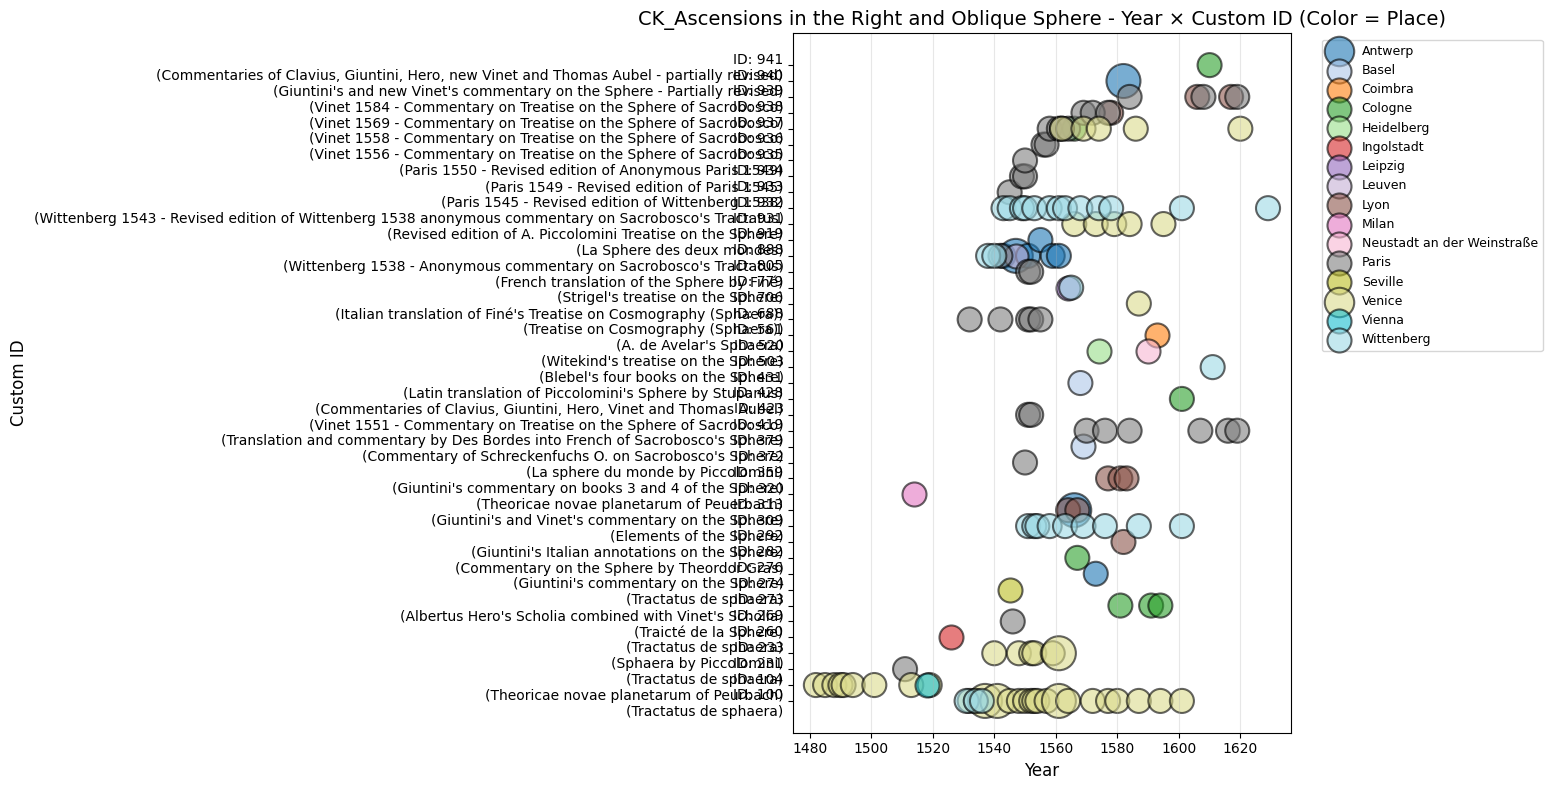


=== CK_Relations between Arcs of the Zodiac and the Equinoctial ===
Rows: 22, Books: 22, Images: 22


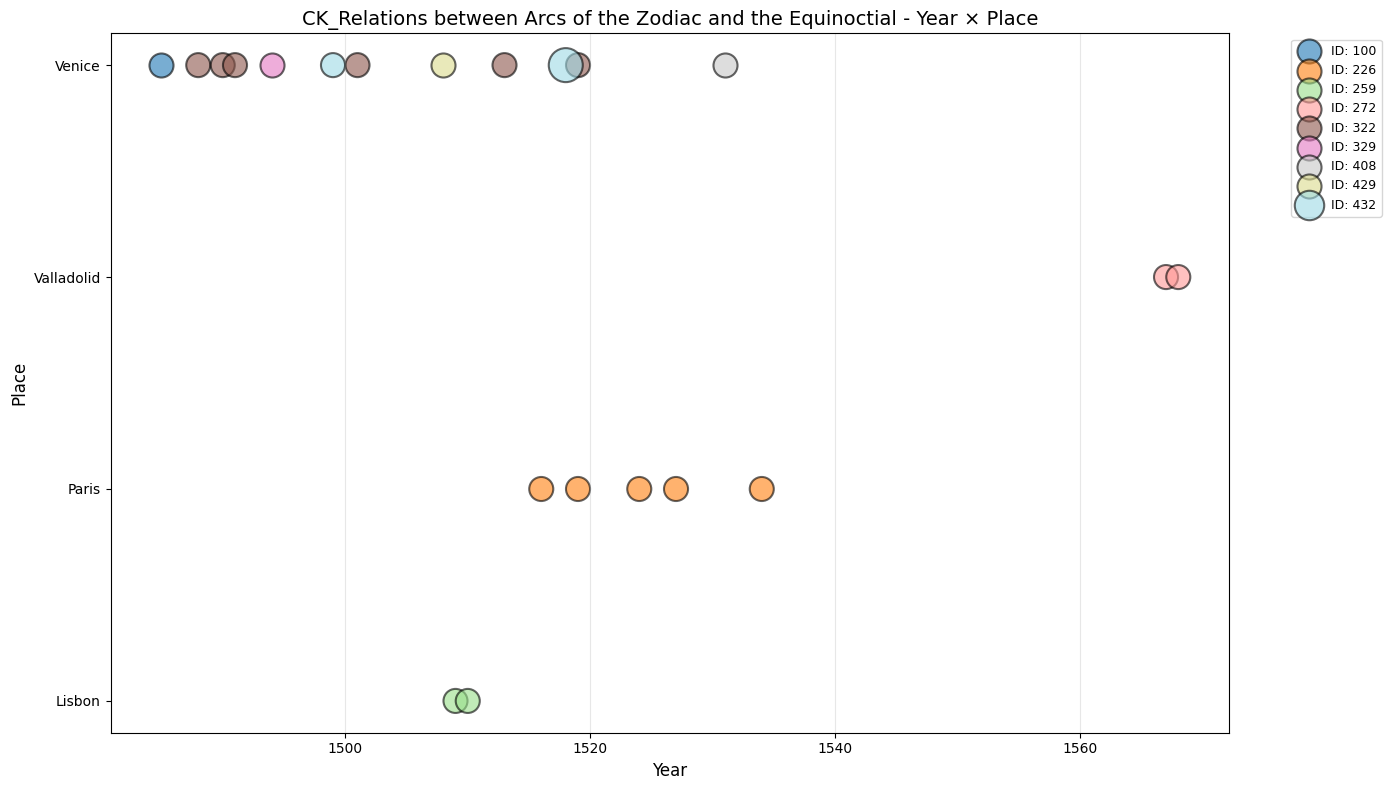

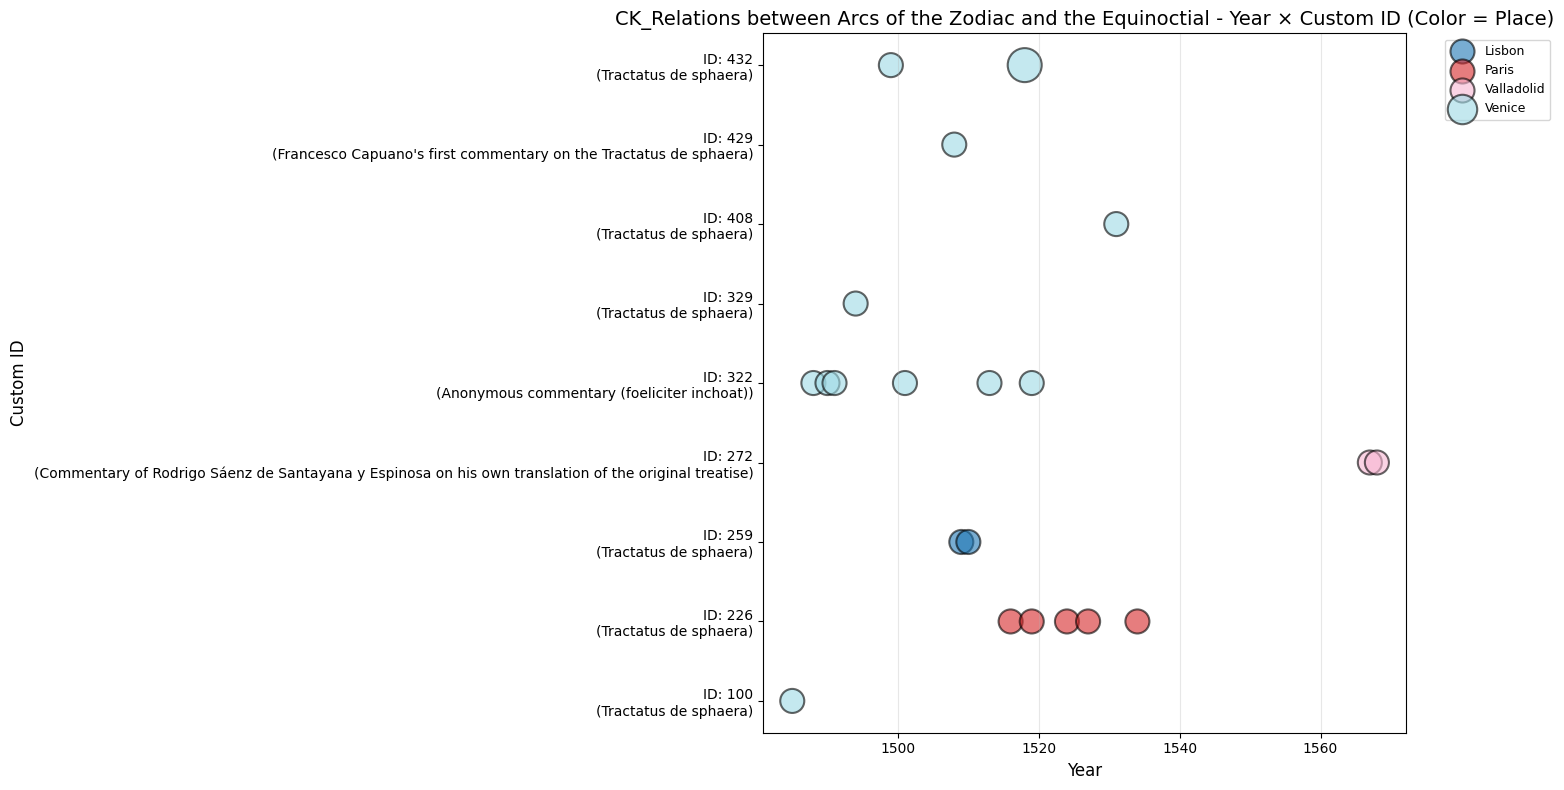

In [100]:
# INDIVIDUAL ASCENSIONS
for cks_val in asc_cks:
    asc_individual = df[df['cks'] == cks_val].copy()
    
    print(f"\n=== {cks_val} ===")
    print(f"Rows: {asc_individual.shape[0]}, Books: {asc_individual['book'].nunique()}, Images: {asc_individual['images'].nunique()}")
    
    make_scatter_plots(asc_individual, cks_val)